# Global Cybersecurity Threats Analysis (2015-2024)

## Overview
This analysis examines 3,000 global cybersecurity incidents recorded
between 2015 and 2024. It identifies key patterns across attack types,
targeted industries, threat actors, and financial impact.

- **Dataset:** Global Cybersecurity Threats (2015-2024) - Kaggle
- **Tools:** Python, Pandas, Matplotlib, Seaborn
- **Author:** HT Olugbade

In [2]:
# Import pandas - our data analysis tool 
import pandas as pd

# Load the dataset
df = pd.read_csv('Global_Cybersecurity_Threats_2015-2024.csv')

# Check structure
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   str    
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   str    
 3   Target Industry                      3000 non-null   str    
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   str    
 7   Security Vulnerability Type          3000 non-null   str    
 8   Defense Mechanism Used               3000 non-null   str    
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 234.5 KB


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [3]:
# Summary statistics - understand the numbers
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [4]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [5]:
# What categories exist in each text column?
cat_columns = ['Attack Type', 'Target Industry',
               'Country', 'Attack Source',
               'Security Vulnerability Type',
               'Defense Mechanism Used']

for col in cat_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Attack Type ---
Attack Type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

--- Target Industry ---
Target Industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403
Name: count, dtype: int64

--- Country ---
Country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

--- Attack Source ---
Attack Source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

--- Security Vulnerability Type ---
Security Vulnerability Type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: cou

In [7]:
# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look clean and professional
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries ready!")

Libraries ready!


### 1. Distribution of Cyber Attack Types
**Question:** Which attack methods are most commonly used against organisations?

C:\Users\DELE\AppData\Local\Temp\ipykernel_17808\3071799030.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attack Type',


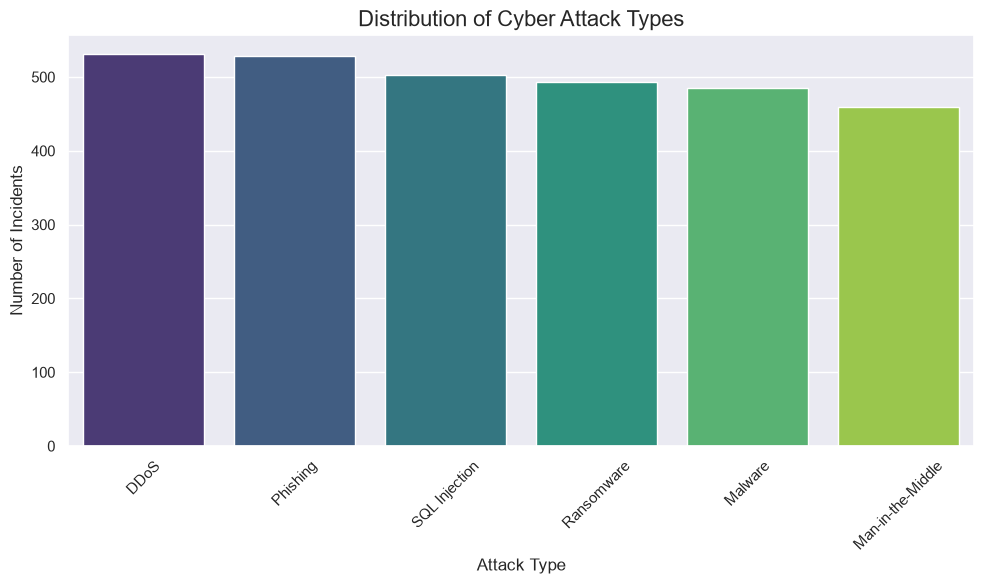

In [8]:
# Chart 1 - Attack Types Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Attack Type',
              palette='viridis',
              order=df['Attack Type'].value_counts().index)
plt.title('Distribution of Cyber Attack Types', fontsize=16)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** DDoS and Phishing lead with 531 and 529 incidents respectively.
All six attack types are evenly distributed, indicating attackers
use diverse methods rather than favouring one approach.

### 2. Cyber Attacks by Target Industry
**Question:** Which industries are most vulnerable to cyber attacks?

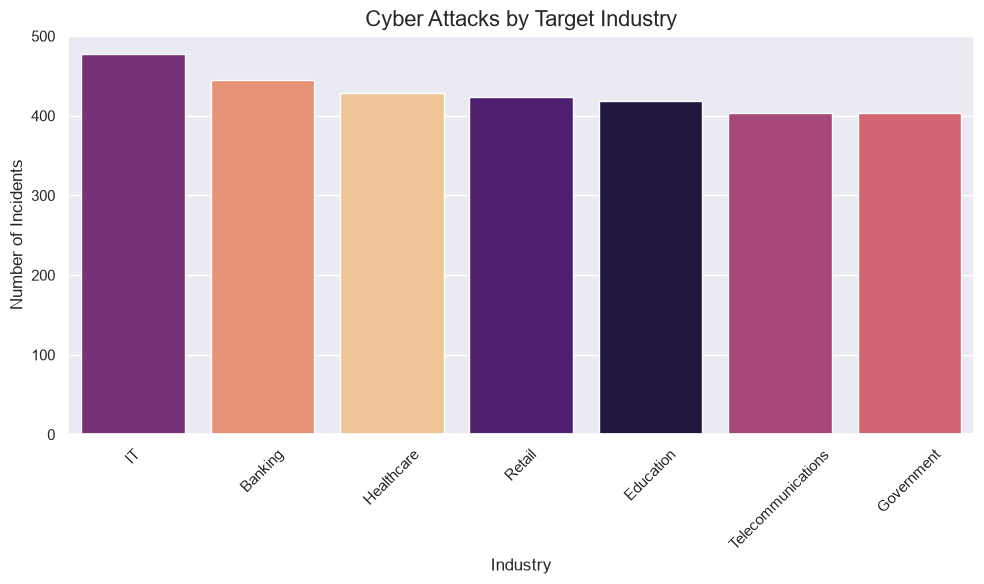

In [9]:
# Chart 2 - Target Industries
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Target Industry',
              hue='Target Industry',
              palette='magma',
              legend=False,
              order=df['Target Industry'].value_counts().index)
plt.title('Cyber Attacks by Target Industry', fontsize=16)
plt.xlabel('Industry', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** The IT sector is the most targeted industry (478 incidents),
followed by Banking and Healthcare. All seven sectors face significant
risk, highlighting that no industry is immune.

### 3. Cyber Attacks by Country
**Question:** Which countries experience the highest number of cyber incidents?

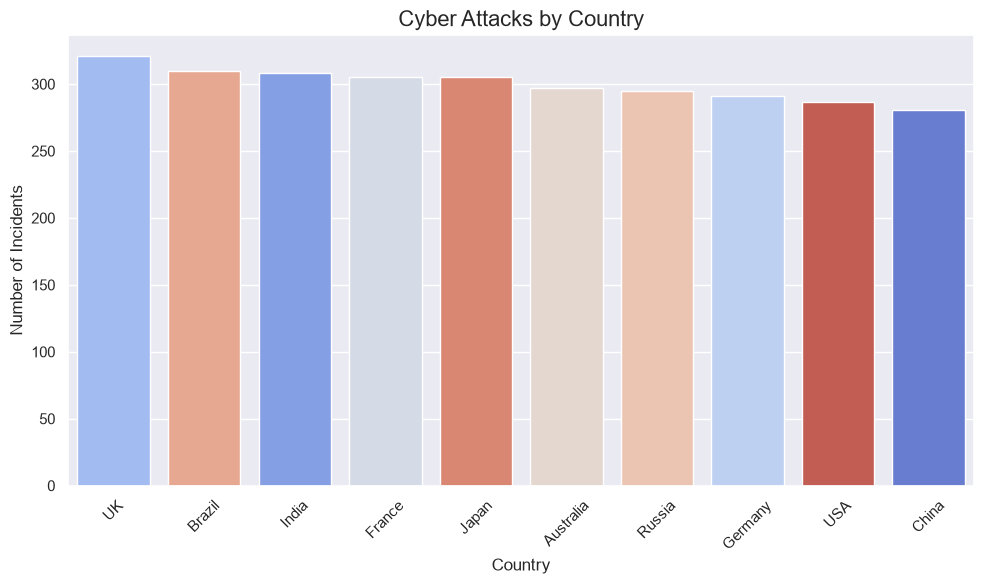

In [10]:
# Chart 3 - Attacks by Country
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Country',
              hue='Country',
              palette='coolwarm',
              legend=False,
              order=df['Country'].value_counts().index)
plt.title('Cyber Attacks by Country', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding:** The UK records the most incidents (321), followed by Brazil
and India. The narrow gap between all 10 countries confirms that
cyber threats are a global challenge, not regional.

### 4. Cyber Attacks by Source
**Question:** Who is responsible for cyber attacks?

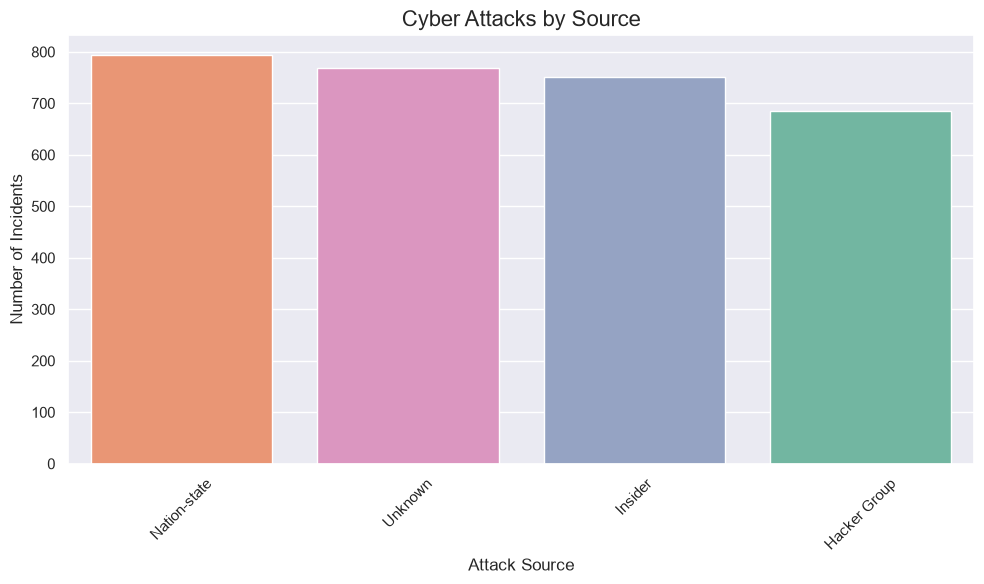

In [11]:
# Chart 4 - Attack Sources
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Attack Source',
              hue='Attack Source',
              palette='Set2',
              legend=False,
              order=df['Attack Source'].value_counts().index)
plt.title('Cyber Attacks by Source', fontsize=16)
plt.xlabel('Attack Source', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Finding:** Nation-state actors are the leading threat source (794 incidents),
followed closely by Unknown actors (768) and Insiders (752).
Over 25% of attacks are government-sponsored - a significant geopolitical risk.

### 5. Average Financial Loss per Year (2015-2024)
**Question:** How has the financial impact of cyber attacks changed over time?

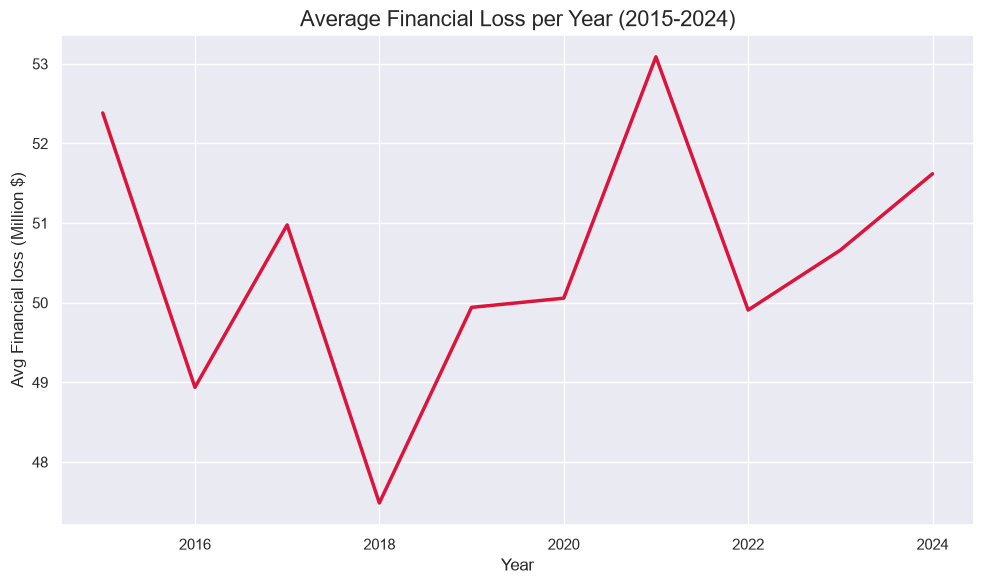

In [12]:
# Chart 5 - Average Financial Loss by Year
yearly_loss = df.groupby('Year')['Financial Loss (in Million $)'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly_loss, x='Year',
             y='Financial Loss (in Million $)',
             markers='o', color='crimson', linewidth=2.5)
plt.title('Average Financial Loss per Year (2015-2024)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Avg Financial loss (Million $)', fontsize=12)
plt.tight_layout()
plt.show()

**Finding:** Average financial losses fluctuate between $48M and $53M annually,
peaking in 2021. The upward recovery into 2024 suggests the financial
cost of cyber attacks is growing over time.

## Key Findings

This analysis of 3,000 global cybersecurity incidents (2015-2024)
reveals the following:

1. **DDoS and phishing** are the most common attack methods,
each exceeding 500 incidents across the dataset.

2. **IT and Banking** are the most targeted industries,
though all sectors face significant and comparable risk.

3. **The UK** recorded the highest number of incidents,
but attacks are distributed globally with no single country
dramatically more exposed than others.

4. **Nation-state Actors** are the leading threat source,
responsible for over 794 incidents, highlighting a serious
geopolitical dimension to cybersecurity risk.

5. **Financial losses** average between $48M and $53M per year,
with an upward trend into 2024 indicating growing economic impact.

## Conclusion
Cyber threats are a global, cross-industry challenge driven increasingly
by state-sponsored actors. Organisations must adopt multi-layered
defense strategies to protect against diverse and evolving attack methods.